In [1]:
# Install dependencies
!pip install -q timm

In [2]:
# Mount Google Drive
# Expected layout in Drive:
# MyDrive
# ├── ucsc-cse-144-spring-2026-final-project
# │   ├── train
# │   ├── test
# |   ├── sample_submission.csv
from google.colab import drive
drive.mount("/content/drive")

import os
DATA_ROOT = "/content/drive/MyDrive/ucsc-cse-144-spring-2026-final-project"
CKPT_DIR = f"{DATA_ROOT}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok = True)

assert os.path.isdir(f"{DATA_ROOT}/train"), f"train/ not found at {DATA_ROOT}"
assert os.path.isdir(f"{DATA_ROOT}/test"), f"test/ not found at {DATA_ROOT}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from collections import defaultdict
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import timm
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "none")

def set_seed(seed: int = 42):
  """Make results reproducible across runs."""
  os.environ["PYTHONHASHSEED"] = str(seed)
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

Device: cuda
GPU: Tesla T4


In [4]:
# Transforms
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Augment training data since we only have 10 images/class
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale = (0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25),
])

# Just resize and normalize eval data
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [5]:
# ImageFolder maps class dirs to integer labels in sorted-string order
# So by default '10' would be mapped to label 2 instead of 10
class RemappedImageFolder(ImageFolder):
  def __init__(self, root, transform = None):
    super().__init__(root, transform = transform)
    self.remap = {i: int(name) for i, name in enumerate(self.classes)}
    # Rebuild samples with corrected labels
    self.samples = [(p, self.remap[t]) for p, t in self.samples]
    self.targets = [t for _, t in self.samples]

# Get training set
train_set = RemappedImageFolder(f"{DATA_ROOT}/train", transform = train_tf)
print("Num train images:", len(train_set))
print("Num classes:", len(set(train_set.targets)))
# Sanity check the mapping
print("Five samples (path -> label):")
for p, t in train_set.samples[:50:10]:
  print(" ", p, "->", t)

# Hold out 1 image per class as a tiny validation set
by_class = defaultdict(list)
for idx, t in enumerate(train_set.targets):
  by_class[t].append(idx)

rng = random.Random(SEED)
val_idx = [rng.choice(v) for v in by_class.values()]
train_idx = [i for i in range(len(train_set)) if i not in set(val_idx)]

# Split into training and validation subsets
train_subset = Subset(train_set, train_idx)
val_set_raw = RemappedImageFolder(f"{DATA_ROOT}/train", transform = eval_tf)
val_subset = Subset(val_set_raw, val_idx)
print(f"Train: {len(train_subset)}, Val: {len(val_subset)}")

Num train images: 1079
Num classes: 100
Five samples (path -> label):
  /content/drive/MyDrive/ucsc-cse-144-spring-2026-final-project/train/0/0.jpg -> 0
  /content/drive/MyDrive/ucsc-cse-144-spring-2026-final-project/train/1/10.jpg -> 1
  /content/drive/MyDrive/ucsc-cse-144-spring-2026-final-project/train/10/100.jpg -> 10
  /content/drive/MyDrive/ucsc-cse-144-spring-2026-final-project/train/11/110.jpg -> 11
  /content/drive/MyDrive/ucsc-cse-144-spring-2026-final-project/train/12/120.jpg -> 12
Train: 979, Val: 100


In [6]:
# Test dataset (files named 0.jpg, ..., 999.jpg)
class TestDataset(Dataset):
  def __init__(self, root, transform = None):
    self.root = Path(root)
    # Sort numerically by filename stem
    self.files = sorted(self.root.glob("*.jpg"), key = lambda p: int(p.stem))
    self.transform = transform

  def __len__(self):
    return len(self.files)

  def __getitem__(self, i):
    img = Image.open(self.files[i]).convert("RGB")
    if self.transform:
      img = self.transform(img)
    return img, int(self.files[i].stem)

test_set = TestDataset(f"{DATA_ROOT}/test", transform = eval_tf)
print("Num test images:", len(test_set))

Num test images: 1036


In [7]:
# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_subset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    pin_memory = True,
    drop_last = False,
    persistent_workers = True,
)

val_loader = DataLoader(
    val_subset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2,
    pin_memory = True,
)

test_loader = DataLoader(
    test_set,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2,
    pin_memory = True,
)

In [8]:
# Trying ConvNeXt-Tiny (in22k).
# timm handles the head replacement automatically when you pass num_classes = 100
NUM_CLASSES = 100
model = timm.create_model(
    "convnext_tiny.fb_in22k_ft_in1k",
    pretrained = True,
    num_classes = NUM_CLASSES,
)
model = model.to(DEVICE)
print("Params:", sum(p.numel() for p in model.parameters()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Params: 27897028


In [9]:
# Optimizer, scheduler, loss
EPOCHS = 30
LR = 3e-4
WD = 1e-4

# AdamW with cosine schedule + brief warmup
optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing = 0.1)

# Mixed precision to speed things up
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_11758/3506999361.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [10]:
# Train and eval loop
def evaluate(loader):
  model.eval()
  correct, total = 0, 0
  with torch.no_grad():
    for x, y in loader:
      x, y = x.to(DEVICE), y.to(DEVICE)
      with torch.cuda.amp.autocast():
        out = model(x)
      correct += (out.argmax(1) == y).sum().item()
      total += y.size(0)
  return correct / total

history = {"train_loss": [], "train_acc": [], "val_acc": [], "lr": []}

best_val = 0.0
for epoch in range(EPOCHS):
  model.train()
  running_loss, running_correct, running_total = 0.0, 0, 0
  for x, y in train_loader:
    x, y = x.to(DEVICE), y.to(DEVICE)
    optimizer.zero_grad()
    with torch.cuda.amp.autocast():
      out = model(x)
      loss = criterion(out, y)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    running_loss += loss.item() * x.size(0)
    running_correct += (out.argmax(1) == y).sum().item()
    running_total += y.size(0)
  scheduler.step()

  train_loss = running_loss / running_total
  train_acc = running_correct / running_total
  val_acc = evaluate(val_loader)

  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["val_acc"].append(val_acc)
  history["lr"].append(scheduler.get_last_lr()[0])

  print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"loss {train_loss:.3f} | "
        f"train {train_acc:.3f} | val {val_acc:.3f} | "
        f"lr {scheduler.get_last_lr()[0]:.2e}")

  if val_acc > best_val:
    best_val = val_acc
    torch.save(model.state_dict(), f"{CKPT_DIR}/best.pt")
    print(f"Saved new best ({best_val:.3f})")

print("Best val acc:", best_val)

import json
with open(f"{CKPT_DIR}/history.json", "w") as f:
  json.dump(history, f)

/tmp/ipykernel_11758/1797434367.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_11758/1797434367.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/30 | loss 3.767 | train 0.231 | val 0.350 | lr 2.99e-04
Saved new best (0.350)
Epoch 02/30 | loss 2.177 | train 0.575 | val 0.560 | lr 2.97e-04
Saved new best (0.560)
Epoch 03/30 | loss 1.584 | train 0.760 | val 0.650 | lr 2.93e-04
Saved new best (0.650)
Epoch 04/30 | loss 1.273 | train 0.865 | val 0.670 | lr 2.87e-04
Saved new best (0.670)
Epoch 05/30 | loss 1.110 | train 0.911 | val 0.660 | lr 2.80e-04
Epoch 06/30 | loss 1.064 | train 0.932 | val 0.660 | lr 2.71e-04
Epoch 07/30 | loss 0.971 | train 0.970 | val 0.700 | lr 2.61e-04
Saved new best (0.700)
Epoch 08/30 | loss 0.950 | train 0.966 | val 0.690 | lr 2.50e-04
Epoch 09/30 | loss 0.935 | train 0.972 | val 0.740 | lr 2.38e-04
Saved new best (0.740)
Epoch 10/30 | loss 0.925 | train 0.974 | val 0.690 | lr 2.25e-04
Epoch 11/30 | loss 0.913 | train 0.974 | val 0.700 | lr 2.11e-04
Epoch 12/30 | loss 0.904 | train 0.978 | val 0.660 | lr 1.96e-04
Epoch 13/30 | loss 0.877 | train 0.984 | val 0.680 | lr 1.81e-04
Epoch 14/30 | los

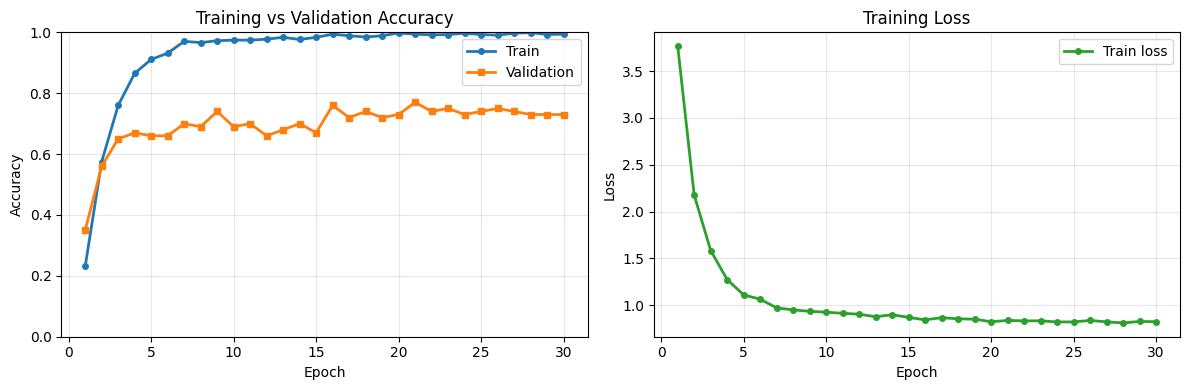

Saved to: /content/drive/MyDrive/ucsc-cse-144-spring-2026-final-project/training_curve.png


In [11]:
# Plot training and validation curves
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy curve
ax1.plot(epochs, history["train_acc"], label="Train", linewidth=2, marker="o", markersize=4)
ax1.plot(epochs, history["val_acc"], label="Validation", linewidth=2, marker="s", markersize=4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_title("Training vs Validation Accuracy")
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1)

# Loss curve
ax2.plot(epochs, history["train_loss"], label="Train loss", linewidth=2, marker="o", markersize=4, color="C2")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Training Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATA_ROOT}/training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to:", f"{DATA_ROOT}/training_curve.png")

In [12]:
# Load best weights and predict on test set
model.load_state_dict(torch.load(f"{CKPT_DIR}/best.pt", map_location = DEVICE))
model.eval()

ids, preds = [], []
with torch.no_grad():
  for x, batch_ids in test_loader:
    x = x.to(DEVICE)
    with torch.cuda.amp.autocast():
      out = model(x)
    preds.extend(out.argmax(1).cpu().tolist())
    ids.extend(batch_ids.tolist())

sub = pd.DataFrame({
    "ID": [f"{i}.jpg" for i in ids],
    "Label": preds
}).sort_values("ID", key = lambda col: col.str.replace(".jpg", "").astype(int))
sub.to_csv("/content/submission.csv", index = False)
sub.to_csv(f"{DATA_ROOT}/submission.csv", index = False)
print(sub.head())
print("Wrote submission.csv with", len(sub), "rows")

/tmp/ipykernel_11758/1957744244.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


      ID  Label
0  0.jpg     62
1  1.jpg     43
2  2.jpg     38
3  3.jpg     62
4  4.jpg     42
Wrote submission.csv with 1036 rows


In [13]:
from google.colab import files
files.download("/content/submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>